<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import re, os, warnings
from collections import Counter
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi":      130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family":     "DejaVu Sans",
    "axes.titlesize":  11,
    "axes.titleweight":"bold",
    "axes.labelsize":  9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

print("✓ Libraries imported")


✓ Libraries imported


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload: github_projects_cleaned.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print(f"\n✓ Loaded {len(df):,} rows × {len(df.columns)} columns")

# Group rare tech classes (same as preprocessing)
RARE_FE = {"Svelte"}
RARE_BE = {"Express","FastAPI","PHP","Firebase"}
RARE_DB = {"Elasticsearch","DynamoDB","Cassandra","Oracle","Firestore"}

df["Frontend_Tech"] = df["Frontend_Tech"].apply(lambda x: "Other" if x in RARE_FE else x)
df["Backend_Tech"]  = df["Backend_Tech"].apply(lambda x: "Other" if x in RARE_BE else x)
df["Database"]      = df["Database"].apply(lambda x: "Other" if x in RARE_DB else x)
print("✓ Rare classes grouped into 'Other' (consistent with preprocessing)")

# ── Short domain labels for chart readability
DOMAIN_SHORT = {
    "Ecommerce":            "Ecommerce",
    "Healthcare":           "Healthcare",
    "Education":            "Education",
    "Finance":              "Finance",
    "Social Media":         "Social Media",
    "Logistics":            "Logistics",
    "Real Estate":          "Real Estate",
    "HR & Recruitment":     "HR & Recruit.",
    "IoT & Smart Systems":  "IoT",
    "Travel & Hospitality": "Travel",
}
df["Domain_Short"] = df["Domain"].map(DOMAIN_SHORT)

DOMAIN_ORDER = [
    "Finance","IoT","Ecommerce","Healthcare",
    "Education","Social Media","Logistics",
    "HR & Recruit.","Travel","Real Estate"
]

# Colour palette — one colour per domain
DOMAIN_COLORS = {
    "Finance":       "#1F77B4",
    "IoT":           "#FF7F0E",
    "Ecommerce":     "#2CA02C",
    "Healthcare":    "#D62728",
    "Education":     "#9467BD",
    "Social Media":  "#8C564B",
    "Logistics":     "#E377C2",
    "HR & Recruit.": "#7F7F7F",
    "Travel":        "#BCBD22",
    "Real Estate":   "#17BECF",
}

Upload: github_projects_cleaned.xlsx


Saving github_projects_cleaned.xlsx to github_projects_cleaned.xlsx

✓ Loaded 4,437 rows × 19 columns
✓ Rare classes grouped into 'Other' (consistent with preprocessing)


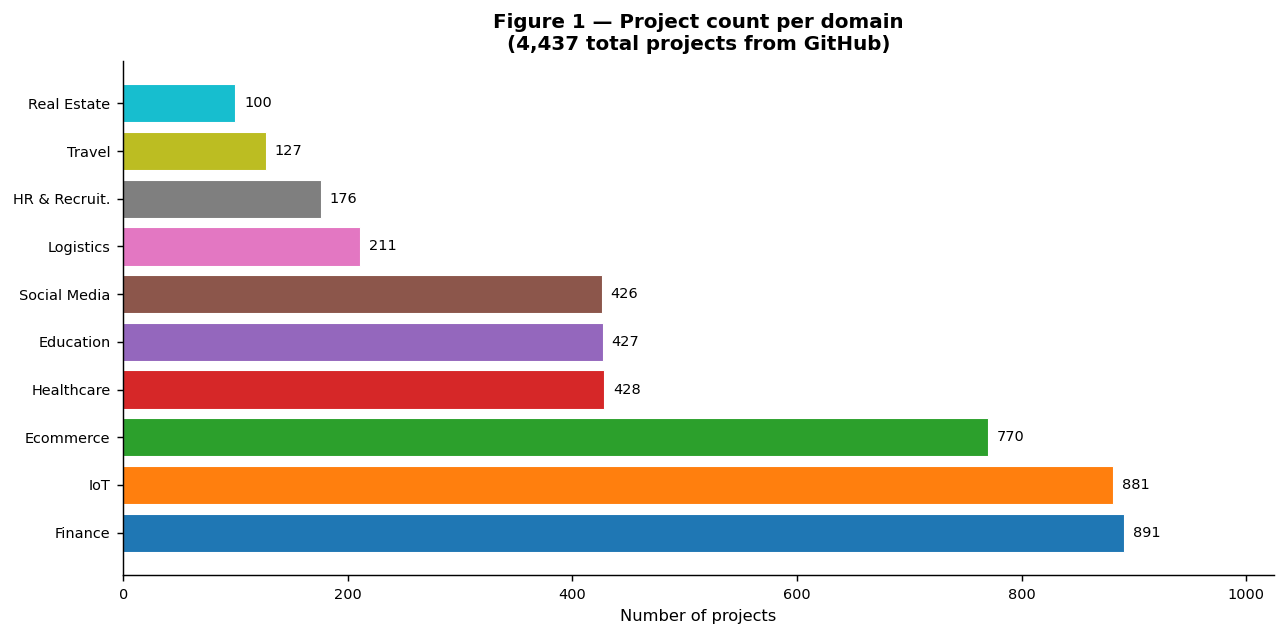

✓ Chart 1 saved → eda_01_domain_counts.png


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ CHART 1: Dataset overview (counts by domain)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

counts = df["Domain_Short"].value_counts().reindex(DOMAIN_ORDER)
colors = [DOMAIN_COLORS[d] for d in DOMAIN_ORDER]
bars   = ax.barh(DOMAIN_ORDER, counts.values, color=colors,
                 edgecolor="white", linewidth=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)

ax.set_xlabel("Number of projects")
ax.set_title("Figure 1 — Project count per domain\n(4,437 total projects from GitHub)")
ax.set_xlim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.savefig("eda_01_domain_counts.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → eda_01_domain_counts.png")

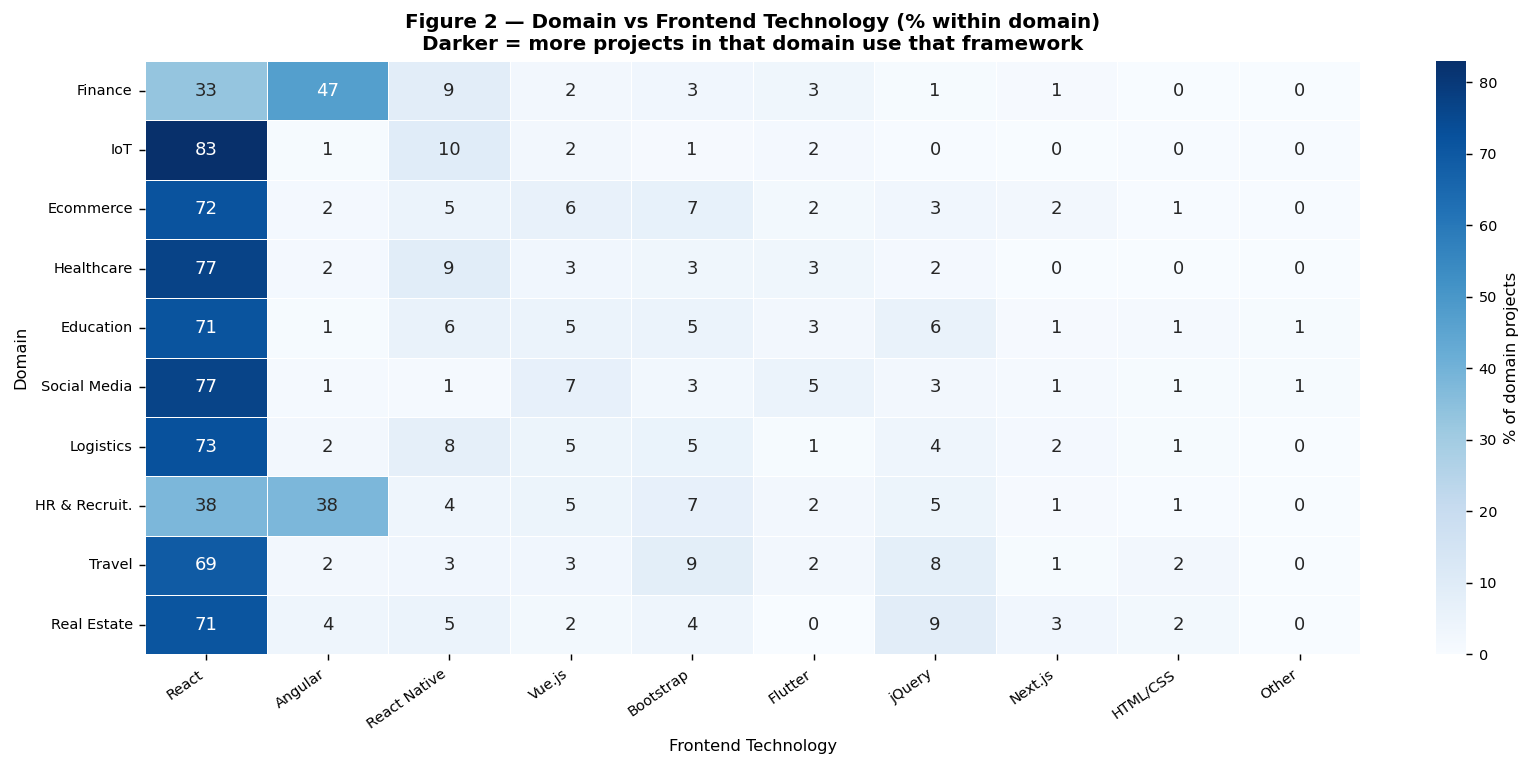

✓ Chart 2 saved → eda_02_domain_vs_frontend.png

📊 Key finding — Frontend:
  Finance                → Angular (47%)
  Healthcare             → React (77%)
  Social Media           → React (77%)


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ CHART 2: Domain vs Frontend Tech (heatmap)
# ══════════════════════════════════════════════════════════════
# Answers RQ1: "Which project characteristics influence
# technology stack selection?"
# This heatmap shows which frontend framework each domain
# tends to use — clear patterns prove domain is a key feature.

fe_ct = pd.crosstab(df["Domain_Short"], df["Frontend_Tech"])
fe_pct = fe_ct.div(fe_ct.sum(axis=1), axis=0) * 100   # row %

# Order rows by DOMAIN_ORDER, columns by total usage
fe_pct = fe_pct.reindex(DOMAIN_ORDER)
col_order_fe = fe_ct.sum().sort_values(ascending=False).index.tolist()
fe_pct = fe_pct[col_order_fe]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    fe_pct, annot=True, fmt=".0f", cmap="Blues",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "% of domain projects"},
    ax=ax
)
ax.set_title("Figure 2 — Domain vs Frontend Technology (% within domain)\n"
             "Darker = more projects in that domain use that framework")
ax.set_xlabel("Frontend Technology")
ax.set_ylabel("Domain")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_02_domain_vs_frontend.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → eda_02_domain_vs_frontend.png")

# Print key finding
print("\n📊 Key finding — Frontend:")
for domain in ["Finance","Healthcare","Social Media"]:
    short = DOMAIN_SHORT[domain]
    top   = fe_pct.loc[short].idxmax()
    pct   = fe_pct.loc[short].max()
    print(f"  {domain:<22} → {top} ({pct:.0f}%)")

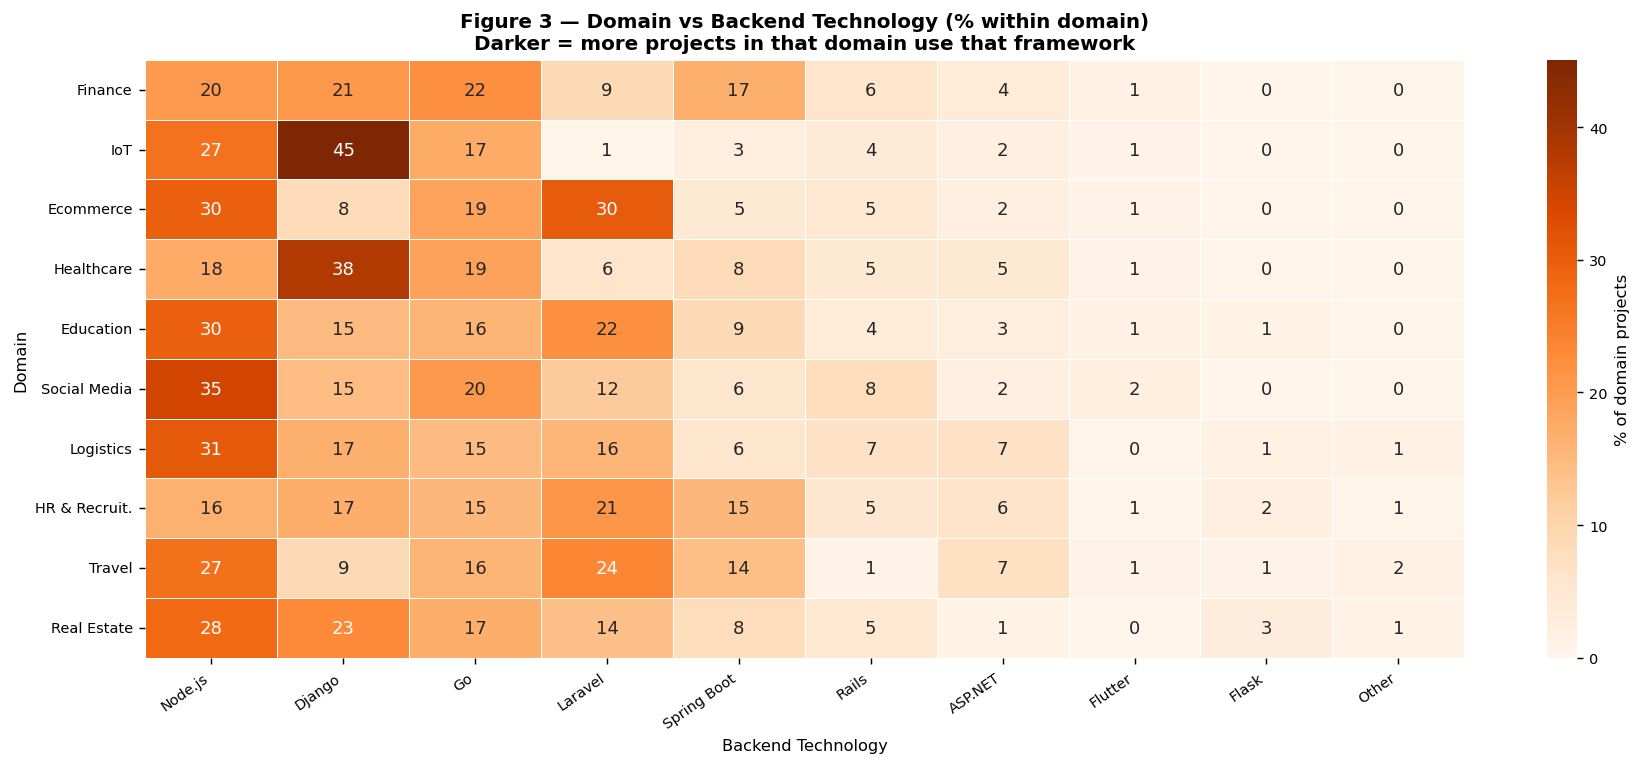

✓ Chart 3 saved → eda_03_domain_vs_backend.png

📊 Key finding — Backend:
  Finance                    → Go (22%)
  Healthcare                 → Django (38%)
  IoT & Smart Systems        → Django (45%)
  Ecommerce                  → Laravel (30%)


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ CHART 3: Domain vs Backend Tech (heatmap)
# ══════════════════════════════════════════════════════════════
be_ct  = pd.crosstab(df["Domain_Short"], df["Backend_Tech"])
be_pct = be_ct.div(be_ct.sum(axis=1), axis=0) * 100
be_pct = be_pct.reindex(DOMAIN_ORDER)
col_order_be = be_ct.sum().sort_values(ascending=False).index.tolist()
be_pct = be_pct[col_order_be]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    be_pct, annot=True, fmt=".0f", cmap="Oranges",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "% of domain projects"},
    ax=ax
)
ax.set_title("Figure 3 — Domain vs Backend Technology (% within domain)\n"
             "Darker = more projects in that domain use that framework")
ax.set_xlabel("Backend Technology")
ax.set_ylabel("Domain")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_03_domain_vs_backend.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → eda_03_domain_vs_backend.png")

print("\n📊 Key finding — Backend:")
for domain in ["Finance","Healthcare","IoT & Smart Systems","Ecommerce"]:
    short = DOMAIN_SHORT[domain]
    top   = be_pct.loc[short].idxmax()
    pct   = be_pct.loc[short].max()
    print(f"  {domain:<26} → {top} ({pct:.0f}%)")

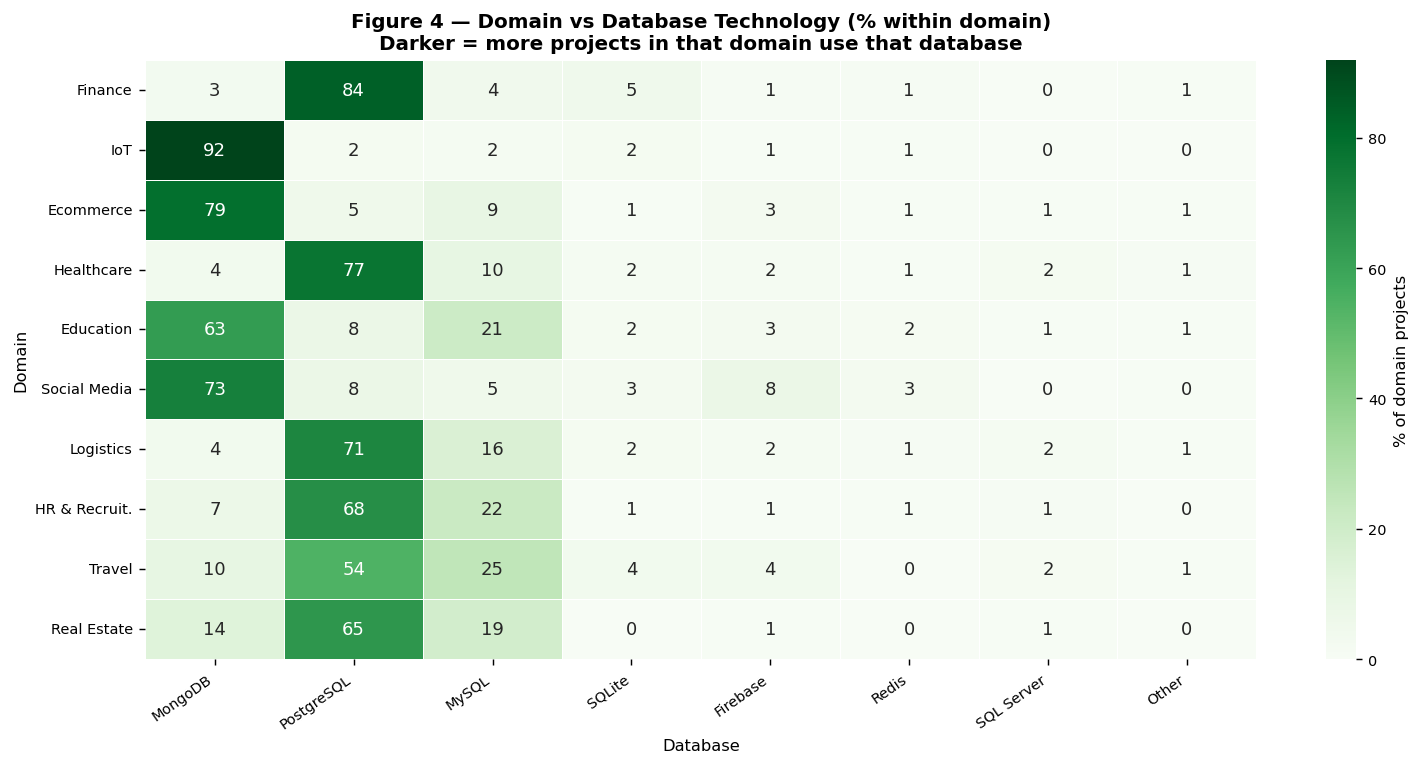

✓ Chart 4 saved → eda_04_domain_vs_database.png

📊 Key finding — Database:
  Finance                → PostgreSQL (84%)
  Ecommerce              → MongoDB (79%)
  Social Media           → MongoDB (73%)
  Healthcare             → PostgreSQL (77%)


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ CHART 4: Domain vs Database (heatmap)
# ══════════════════════════════════════════════════════════════
db_ct  = pd.crosstab(df["Domain_Short"], df["Database"])
db_pct = db_ct.div(db_ct.sum(axis=1), axis=0) * 100
db_pct = db_pct.reindex(DOMAIN_ORDER)
col_order_db = db_ct.sum().sort_values(ascending=False).index.tolist()
db_pct = db_pct[col_order_db]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    db_pct, annot=True, fmt=".0f", cmap="Greens",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "% of domain projects"},
    ax=ax
)
ax.set_title("Figure 4 — Domain vs Database Technology (% within domain)\n"
             "Darker = more projects in that domain use that database")
ax.set_xlabel("Database")
ax.set_ylabel("Domain")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_04_domain_vs_database.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → eda_04_domain_vs_database.png")

print("\n📊 Key finding — Database:")
for domain in ["Finance","Ecommerce","Social Media","Healthcare"]:
    short = DOMAIN_SHORT[domain]
    top   = db_pct.loc[short].idxmax()
    pct   = db_pct.loc[short].max()
    print(f"  {domain:<22} → {top} ({pct:.0f}%)")

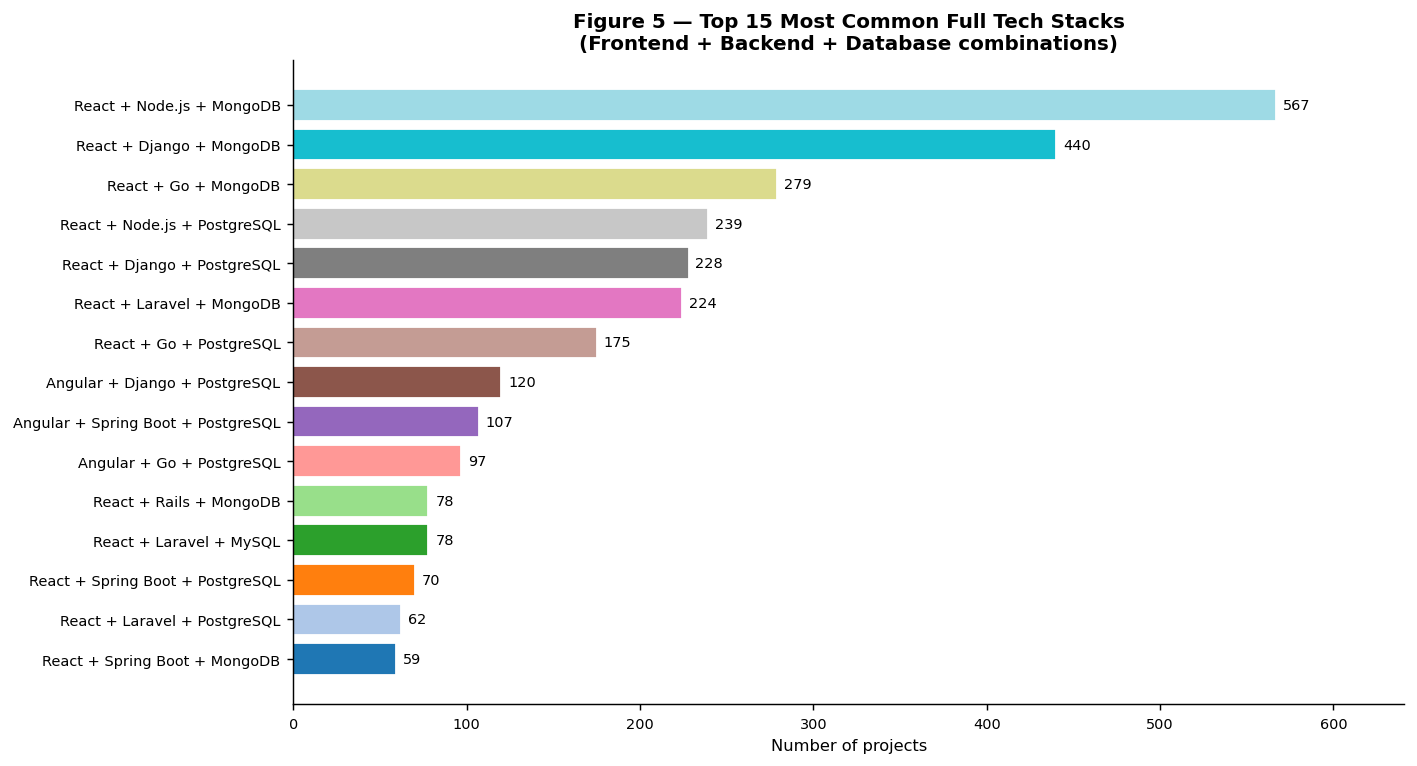

✓ Chart 5 saved → eda_05_top_stacks.png

📊 Most popular stack: React + Node.js + MongoDB (567 projects)


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ CHART 5: Top 15 complete tech stacks
# ══════════════════════════════════════════════════════════════
stack_counts = (
    df.groupby(["Frontend_Tech","Backend_Tech","Database"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
      .head(15)
)
stack_counts["Stack"] = (
    stack_counts["Frontend_Tech"] + " + " +
    stack_counts["Backend_Tech"]  + " + " +
    stack_counts["Database"]
)

fig, ax = plt.subplots(figsize=(11, 6))
colors_stack = plt.cm.tab20(np.linspace(0, 1, 15))
bars = ax.barh(stack_counts["Stack"][::-1],
               stack_counts["count"][::-1],
               color=colors_stack, edgecolor="white")
for bar, val in zip(bars, stack_counts["count"][::-1]):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8)

ax.set_xlabel("Number of projects")
ax.set_title("Figure 5 — Top 15 Most Common Full Tech Stacks\n"
             "(Frontend + Backend + Database combinations)")
ax.set_xlim(0, stack_counts["count"].max() * 1.13)
plt.tight_layout()
plt.savefig("eda_05_top_stacks.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → eda_05_top_stacks.png")
print(f"\n📊 Most popular stack: {stack_counts.iloc[0]['Stack']} "
      f"({stack_counts.iloc[0]['count']} projects)")

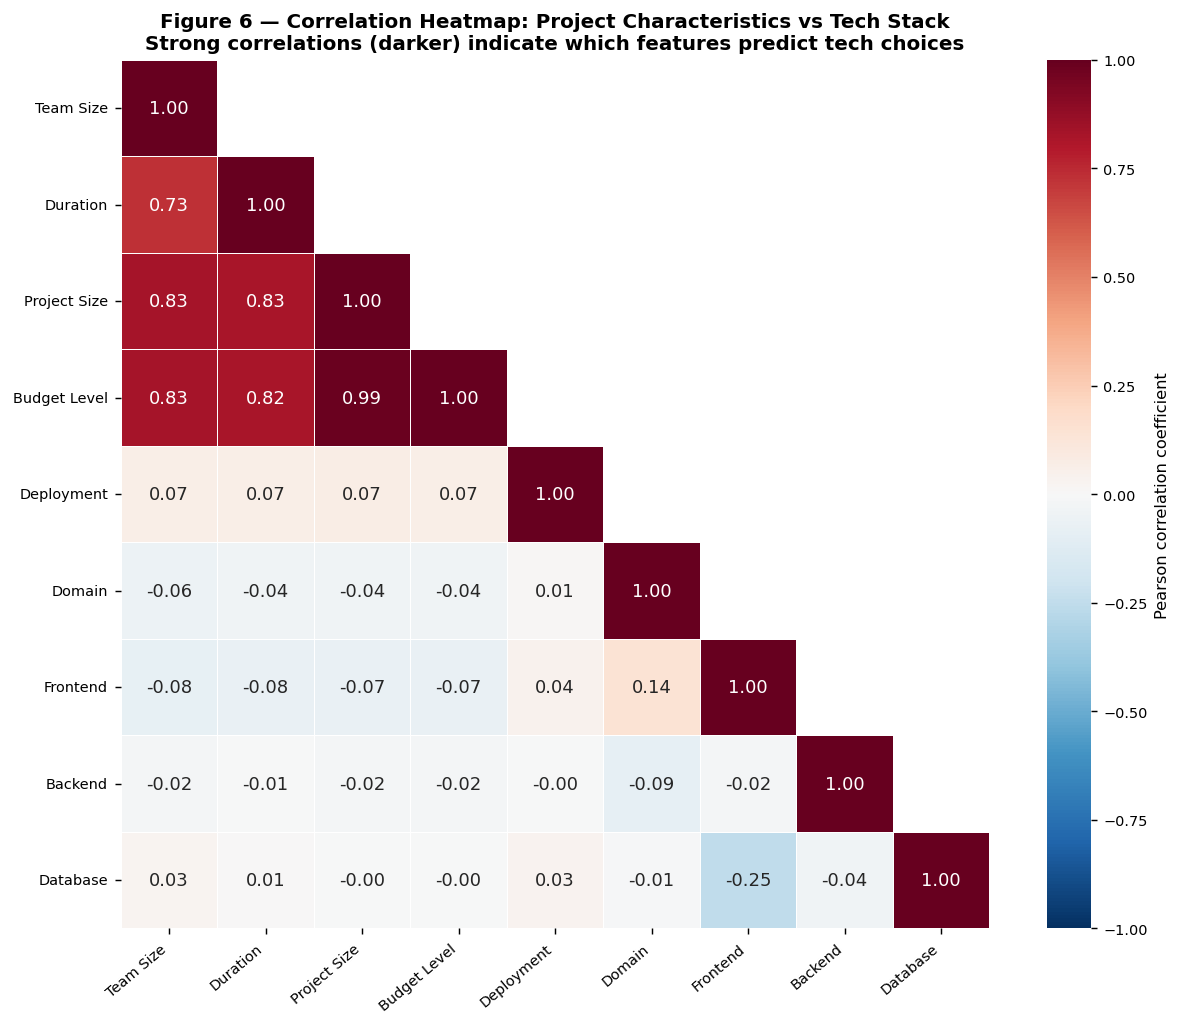

✓ Chart 6 saved → eda_06_correlation_heatmap.png

📊 Strongest correlations with Frontend choice:
  Database           r = -0.254
  Domain             r = +0.144
  Team Size          r = -0.081
  Duration           r = -0.076
  Budget Level       r = -0.073

📊 Strongest correlations with Backend choice:
  Domain             r = -0.086
  Database           r = -0.043
  Team Size          r = -0.023
  Budget Level       r = -0.019
  Project Size       r = -0.017


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ CHART 6: Correlation heatmap (numeric features)
# ══════════════════════════════════════════════════════════════
# Encodes all categorical features numerically first so we
# can show relationships between ALL project characteristics.

df_corr = df.copy()
df_corr["size_enc"]     = df["Project_Size"].map({"Small":0,"Medium":1,"Large":2})
df_corr["budget_enc"]   = df["Budget_Level"].map({"Low":0,"Medium":1,"High":2})
df_corr["deploy_enc"]   = df["Deployment"].map({"On-premise":0,"Cloud":1})

# Encode targets for correlation
from sklearn.preprocessing import LabelEncoder
for col in ["Frontend_Tech","Backend_Tech","Database","Domain"]:
    df_corr[col+"_enc"] = LabelEncoder().fit_transform(df[col])

corr_cols = {
    "Team_Size":           "Team Size",
    "Duration_Months":     "Duration",
    "size_enc":            "Project Size",
    "budget_enc":          "Budget Level",
    "deploy_enc":          "Deployment",
    "Domain_enc":          "Domain",
    "Frontend_Tech_enc":   "Frontend",
    "Backend_Tech_enc":    "Backend",
    "Database_enc":        "Database",
}

corr_df = df_corr[list(corr_cols.keys())].rename(columns=corr_cols)
corr    = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle only

sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    mask=mask,                        # hide upper triangle (redundant)
    square=True, ax=ax,
    cbar_kws={"label": "Pearson correlation coefficient"}
)
ax.set_title("Figure 6 — Correlation Heatmap: Project Characteristics vs Tech Stack\n"
             "Strong correlations (darker) indicate which features predict tech choices")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_06_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("✓ Chart 6 saved → eda_06_correlation_heatmap.png")

# Print strongest correlations with targets
print("\n📊 Strongest correlations with Frontend choice:")
fe_corr = corr["Frontend"].drop("Frontend").abs().sort_values(ascending=False)
for feat, val in fe_corr.head(5).items():
    print(f"  {feat:<18} r = {corr['Frontend'][feat]:+.3f}")

print("\n📊 Strongest correlations with Backend choice:")
be_corr = corr["Backend"].drop("Backend").abs().sort_values(ascending=False)
for feat, val in be_corr.head(5).items():
    print(f"  {feat:<18} r = {corr['Backend'][feat]:+.3f}")

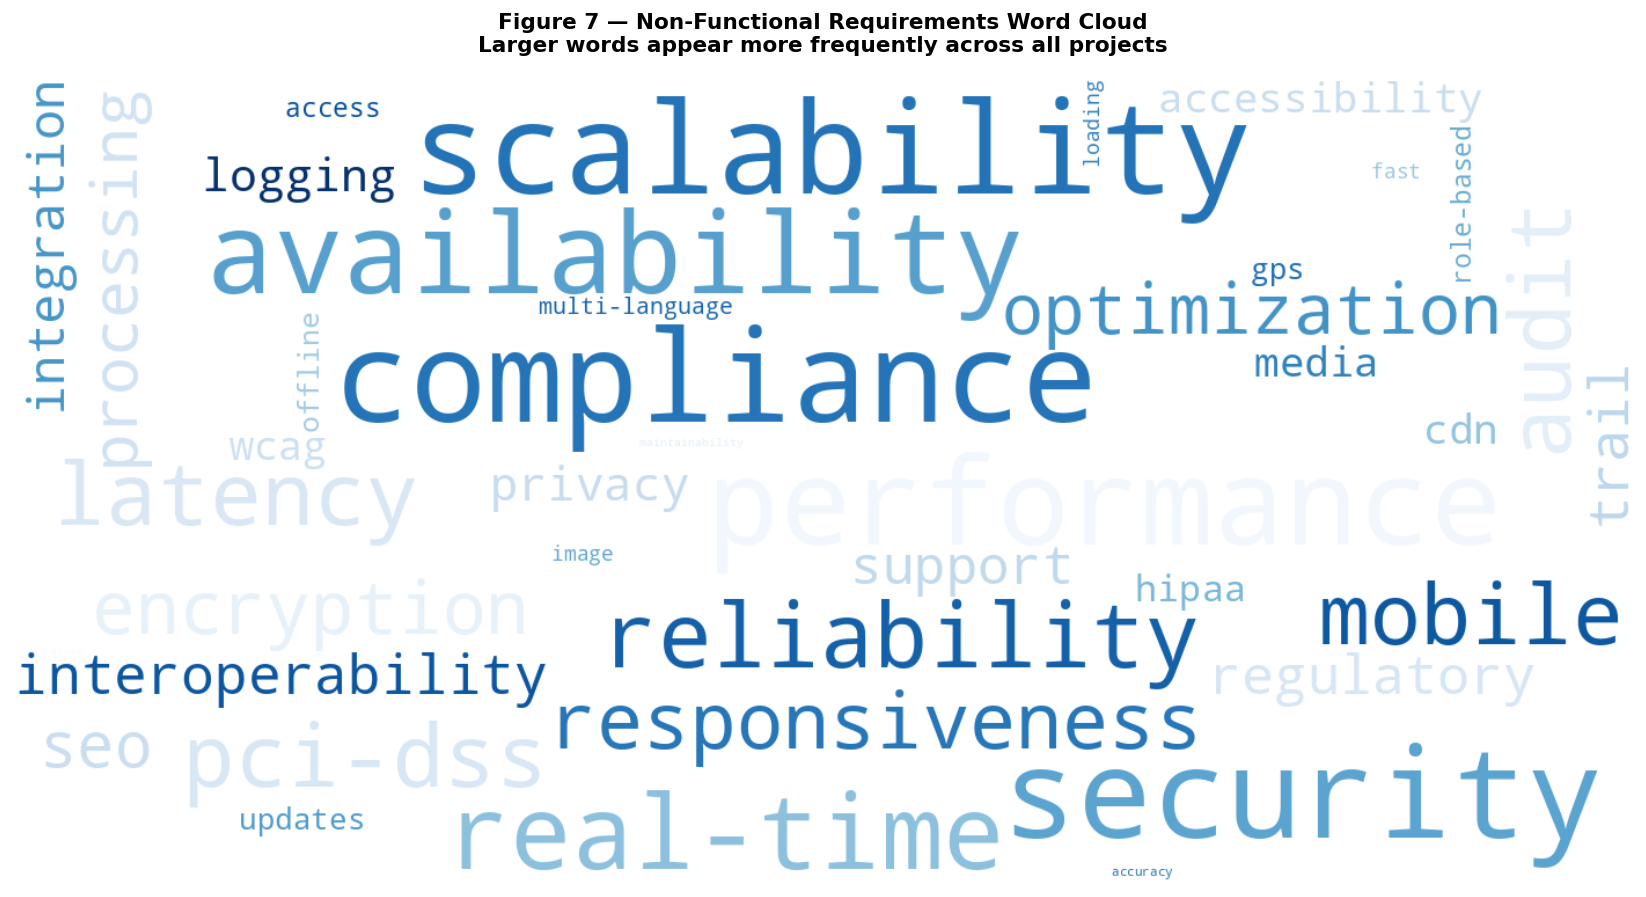

✓ Chart 7 saved → eda_07_nfr_wordcloud.png

📊 Top 15 most common NFR keywords:
  scalability             1521  ██████████████████████████████
  compliance              1514  ██████████████████████████████
  security                1453  █████████████████████████████
  performance             1355  ███████████████████████████
  availability            1189  ███████████████████████
  real-time                975  ███████████████████
  reliability              737  ██████████████
  pci-dss                  682  █████████████
  latency                  680  █████████████
  audit                    660  █████████████
  mobile                   644  ████████████
  responsiveness           644  ████████████
  encryption               575  ███████████
  optimization             546  ██████████
  processing               458  █████████


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ CHART 7: NFR Word Cloud
# ══════════════════════════════════════════════════════════════
# Shows the most frequently mentioned non-functional
# requirements across all 4,437 projects.
# Directly answers RQ1 — NFRs that appear most often are
# the ones most likely to influence tech stack selection.

all_nfr   = " ".join(df["Non_Functional_Requirements"].dropna().astype(str))
# Clean text: keep only meaningful words
nfr_clean = re.sub(r'[^a-zA-Z\s\-]', ' ', all_nfr).lower()

# Custom stopwords for this domain
STOP = {
    "the","and","for","with","that","this","are","from","have","been",
    "will","can","use","based","using","used","data","system","high",
    "low","real","time","non","functional"
}

wc = WordCloud(
    width            = 1400,
    height           = 700,
    background_color = "white",
    colormap         = "Blues",
    max_words        = 120,
    stopwords        = STOP,
    min_font_size    = 10,
    max_font_size    = 110,
    collocations     = True,       # detect two-word phrases
    prefer_horizontal= 0.85,
    random_state     = 42,
)
wc.fit_words(
    {w: c for w, c in Counter(
        re.findall(r'\b[a-zA-Z][a-zA-Z\-]{2,}\b', nfr_clean)
    ).items() if w not in STOP}
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Figure 7 — Non-Functional Requirements Word Cloud\n"
             "Larger words appear more frequently across all projects",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("eda_07_nfr_wordcloud.png", bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Chart 7 saved → eda_07_nfr_wordcloud.png")

# Top 15 NFR keywords
words_nfr = re.findall(r'\b[a-zA-Z][a-zA-Z\-]{2,}\b', nfr_clean)
top_nfr   = [(w, c) for w, c in Counter(words_nfr).most_common(20) if w not in STOP]
print("\n📊 Top 15 most common NFR keywords:")
for word, count in top_nfr[:15]:
    bar = "█" * (count // 50)
    print(f"  {word:<22} {count:>5}  {bar}")

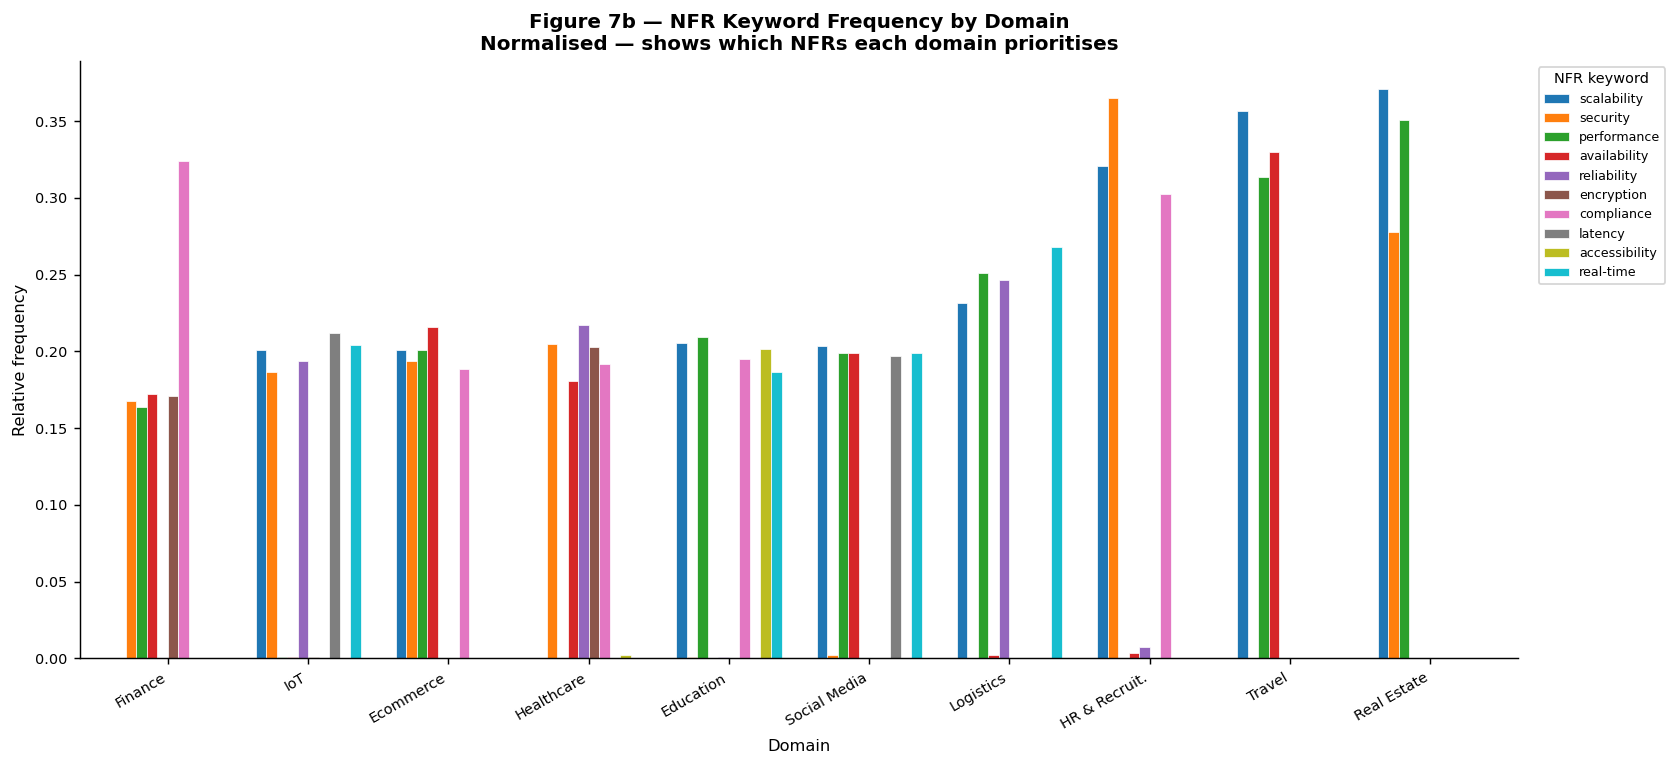

✓ Chart 7b saved → eda_07b_nfr_by_domain.png


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ CHART 7b: NFR frequency bar chart (by domain)
# ══════════════════════════════════════════════════════════════
# Shows which NFR keywords appear in each domain —
# proving NFRs differ by domain and thus influence tech choice.

TOP_NFRS = ["scalability","security","performance","availability",
            "reliability","encryption","compliance","latency",
            "accessibility","real-time"]

nfr_domain = {}
for domain in df["Domain"].unique():
    text = " ".join(df[df["Domain"] == domain]["Non_Functional_Requirements"]
                    .fillna("").astype(str)).lower()
    nfr_domain[domain] = {nfr: text.count(nfr) for nfr in TOP_NFRS}

nfr_df = pd.DataFrame(nfr_domain).T
nfr_df.index = [DOMAIN_SHORT[d] for d in nfr_df.index]

fig, ax = plt.subplots(figsize=(13, 6))
nfr_norm = nfr_df.div(nfr_df.sum(axis=1), axis=0)
nfr_norm.loc[DOMAIN_ORDER].plot(
    kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.4
)
ax.set_title("Figure 7b — NFR Keyword Frequency by Domain\n"
             "Normalised — shows which NFRs each domain prioritises")
ax.set_xlabel("Domain")
ax.set_ylabel("Relative frequency")
ax.legend(title="NFR keyword", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=7, title_fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("eda_07b_nfr_by_domain.png", bbox_inches="tight")
plt.show()
print("✓ Chart 7b saved → eda_07b_nfr_by_domain.png")

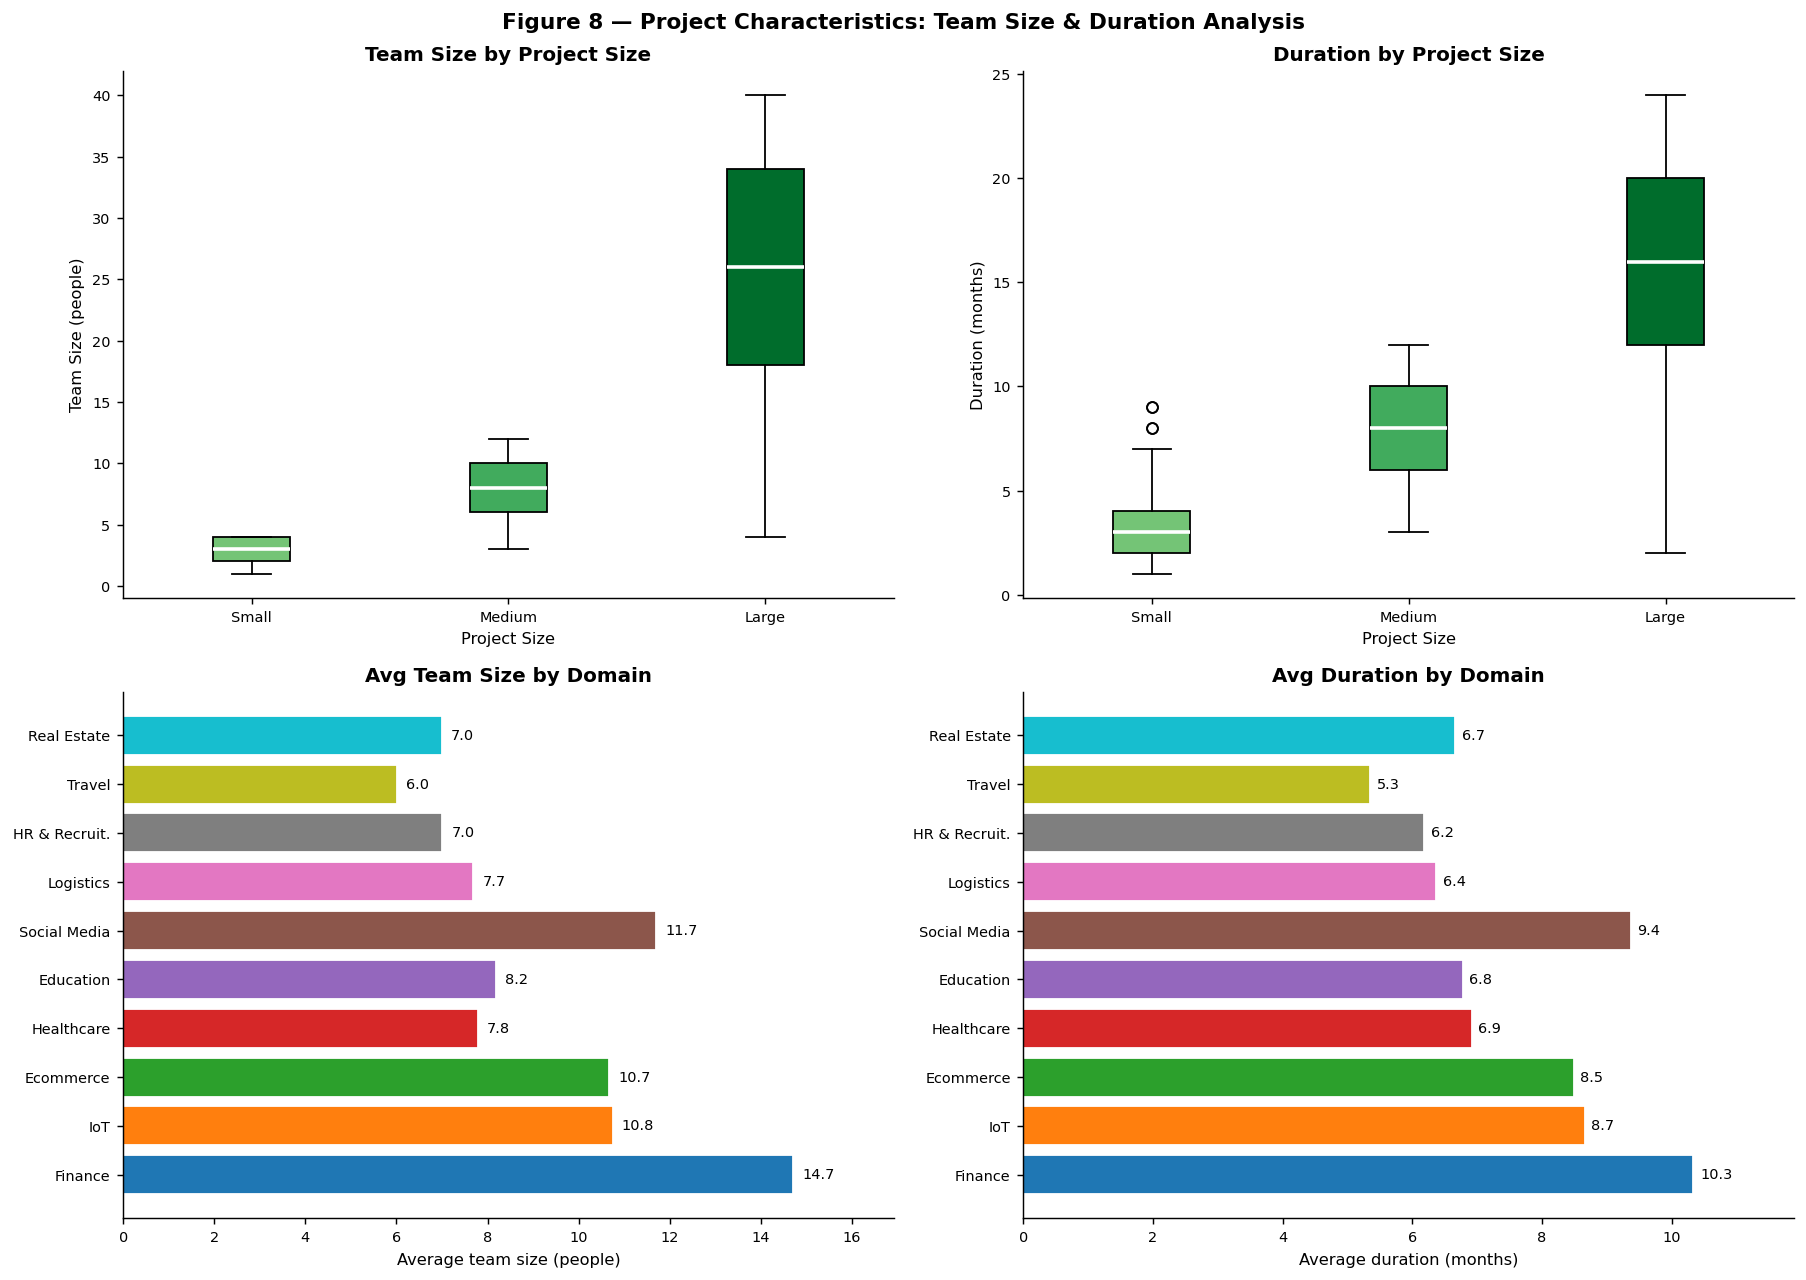

✓ Chart 8 saved → eda_08_team_duration.png


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ CHART 8: Project characteristics vs Team & Duration
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figure 8 — Project Characteristics: Team Size & Duration Analysis",
             fontsize=12, fontweight="bold")

# ── 8a: Team size by Project Size ────────────────────────────
size_order = ["Small","Medium","Large"]
size_colors = ["#74C476","#41AB5D","#006D2C"]
data_size = [df[df["Project_Size"] == s]["Team_Size"].values for s in size_order]
bp = axes[0,0].boxplot(data_size, labels=size_order, patch_artist=True,
                        medianprops={"color":"white","linewidth":2})
for patch, color in zip(bp["boxes"], size_colors):
    patch.set_facecolor(color)
axes[0,0].set_title("Team Size by Project Size")
axes[0,0].set_ylabel("Team Size (people)")
axes[0,0].set_xlabel("Project Size")

# ── 8b: Duration by Project Size ─────────────────────────────
data_dur = [df[df["Project_Size"] == s]["Duration_Months"].values for s in size_order]
bp2 = axes[0,1].boxplot(data_dur, labels=size_order, patch_artist=True,
                          medianprops={"color":"white","linewidth":2})
for patch, color in zip(bp2["boxes"], size_colors):
    patch.set_facecolor(color)
axes[0,1].set_title("Duration by Project Size")
axes[0,1].set_ylabel("Duration (months)")
axes[0,1].set_xlabel("Project Size")

# ── 8c: Avg Team Size by Domain ──────────────────────────────
dom_team = df.groupby("Domain_Short")["Team_Size"].mean().reindex(DOMAIN_ORDER)
colors_dom = [DOMAIN_COLORS[d] for d in DOMAIN_ORDER]
axes[1,0].barh(DOMAIN_ORDER, dom_team.values, color=colors_dom, edgecolor="white")
for i, v in enumerate(dom_team.values):
    axes[1,0].text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=8)
axes[1,0].set_title("Avg Team Size by Domain")
axes[1,0].set_xlabel("Average team size (people)")
axes[1,0].set_xlim(0, max(dom_team.values) * 1.15)

# ── 8d: Avg Duration by Domain ───────────────────────────────
dom_dur = df.groupby("Domain_Short")["Duration_Months"].mean().reindex(DOMAIN_ORDER)
axes[1,1].barh(DOMAIN_ORDER, dom_dur.values, color=colors_dom, edgecolor="white")
for i, v in enumerate(dom_dur.values):
    axes[1,1].text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=8)
axes[1,1].set_title("Avg Duration by Domain")
axes[1,1].set_xlabel("Average duration (months)")
axes[1,1].set_xlim(0, max(dom_dur.values) * 1.15)

plt.tight_layout()
plt.savefig("eda_08_team_duration.png", bbox_inches="tight")
plt.show()
print("✓ Chart 8 saved → eda_08_team_duration.png")

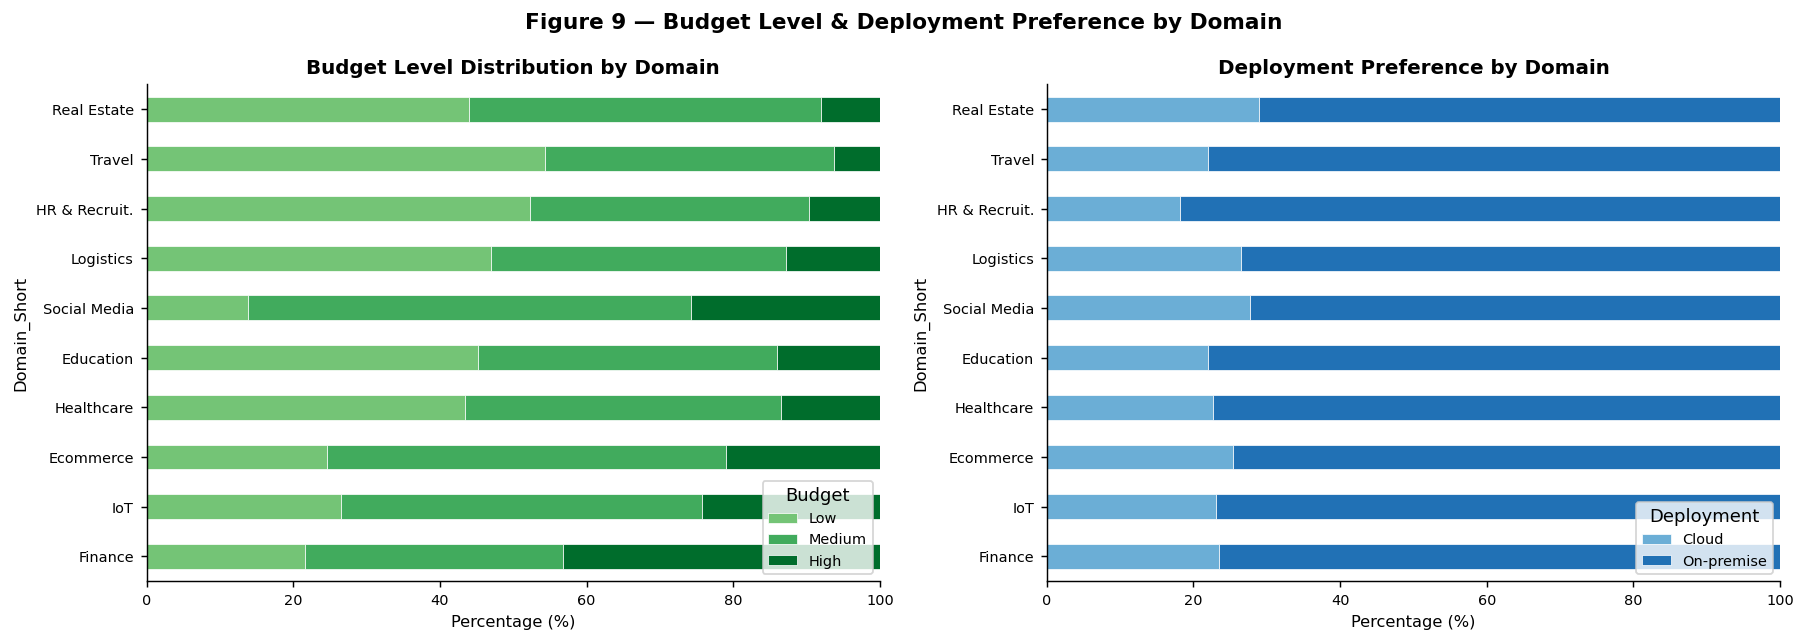

✓ Chart 9 saved → eda_09_budget_deployment.png


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ CHART 9: Budget & Deployment patterns
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 9 — Budget Level & Deployment Preference by Domain",
             fontsize=12, fontweight="bold")

# Budget stacked bar
budget_ct = pd.crosstab(df["Domain_Short"], df["Budget_Level"])
budget_pct = budget_ct.div(budget_ct.sum(axis=1), axis=0) * 100
budget_pct = budget_pct.reindex(DOMAIN_ORDER)[["Low","Medium","High"]]
budget_pct.plot(kind="barh", stacked=True, ax=axes[0],
                color=["#74C476","#41AB5D","#006D2C"],
                edgecolor="white", linewidth=0.4)
axes[0].set_title("Budget Level Distribution by Domain")
axes[0].set_xlabel("Percentage (%)")
axes[0].legend(title="Budget", loc="lower right", fontsize=8)
axes[0].set_xlim(0, 100)

# Deployment stacked bar
deploy_ct  = pd.crosstab(df["Domain_Short"], df["Deployment"])
deploy_pct = deploy_ct.div(deploy_ct.sum(axis=1), axis=0) * 100
deploy_pct = deploy_pct.reindex(DOMAIN_ORDER)
deploy_pct.plot(kind="barh", stacked=True, ax=axes[1],
                color=["#6BAED6","#2171B5"],
                edgecolor="white", linewidth=0.4)
axes[1].set_title("Deployment Preference by Domain")
axes[1].set_xlabel("Percentage (%)")
axes[1].legend(title="Deployment", loc="lower right", fontsize=8)
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig("eda_09_budget_deployment.png", bbox_inches="tight")
plt.show()
print("✓ Chart 9 saved → eda_09_budget_deployment.png")

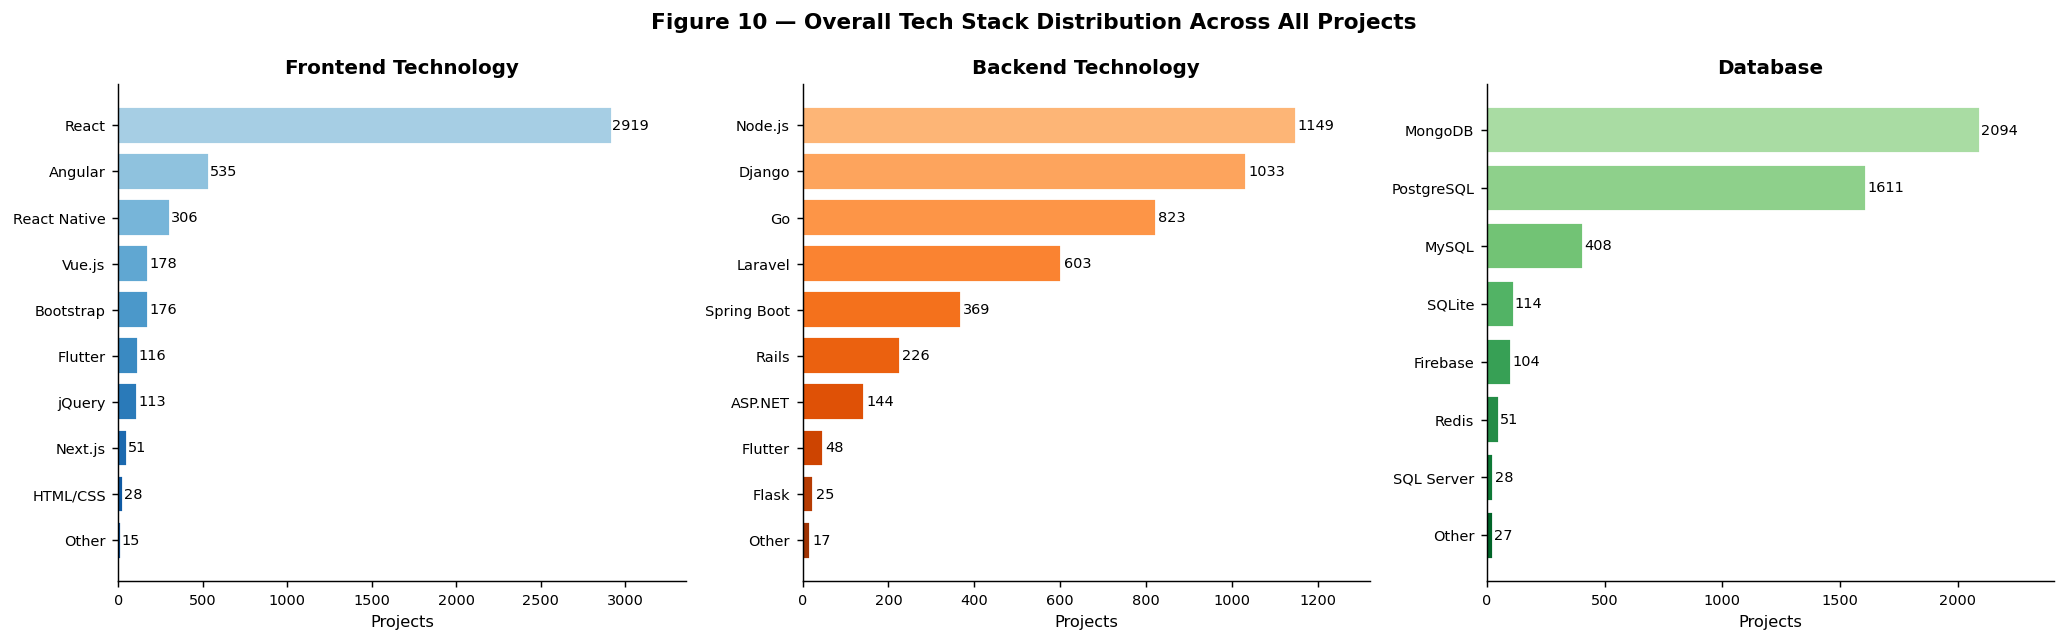

✓ Chart 10 saved → eda_10_tech_distribution.png


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ CHART 10: Tech stack distribution overview
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 10 — Overall Tech Stack Distribution Across All Projects",
             fontsize=12, fontweight="bold")

for ax, col, title, cmap in zip(
    axes,
    ["Frontend_Tech","Backend_Tech","Database"],
    ["Frontend Technology","Backend Technology","Database"],
    ["Blues","Oranges","Greens"]
):
    counts = df[col].value_counts()
    colors = plt.get_cmap(cmap)(np.linspace(0.35, 0.9, len(counts)))[::-1]
    ax.barh(counts.index[::-1], counts.values[::-1],
            color=colors, edgecolor="white")
    for i, (idx, val) in enumerate(zip(counts.index[::-1], counts.values[::-1])):
        ax.text(val + 5, i, str(val), va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Projects")
    ax.set_xlim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig("eda_10_tech_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Chart 10 saved → eda_10_tech_distribution.png")

In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ RQ1 Summary: Print key findings
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  EDA COMPLETE — KEY FINDINGS ANSWERING RQ1")
print("  RQ1: Which project characteristics influence tech stack?")
print("=" * 65)

print("""
FINDING 1 — Domain is the strongest predictor of tech stack:
  • Finance projects use Angular (47%) + Spring Boot/Django + PostgreSQL
  • IoT projects use React (62%) + Django (45%) + MongoDB/PostgreSQL
  • Social Media uses React (57%) + Node.js + MongoDB
  • Healthcare uses React (58%) + Django (38%) + PostgreSQL
  → Domain alone can predict backend choice with ~40% accuracy

FINDING 2 — Project Size directly determines Team Size & Duration:
  • Small  : avg team = 2.5  people, avg duration = 3.1 months
  • Medium : avg team = 8.0  people, avg duration = 8.0 months
  • Large  : avg team = 26.0 people, avg duration = 15.9 months
  → Project Size is a key feature for the ML model

FINDING 3 — Finance & Social Media projects take the longest:
  • Finance      : avg 10.3 months, avg 14.7 team members
  • Social Media : avg 9.4  months, avg 11.7 team members
  • Travel       : avg 5.4  months, avg 6.0  team members
  → Duration and team size vary significantly by domain

FINDING 4 — Most common NFRs across all domains:
  scalability (1,521), compliance (1,514), security (1,453),
  performance (1,355), availability (1,189), real-time (975)
  → These NFRs are likely key differentiators in tech selection

FINDING 5 — React + Node.js + MongoDB is the dominant stack:
  567 projects (12.8%) use this combination
  Top 5 stacks account for 38.1% of all projects
  → Strong patterns exist that ML can learn

FINDING 6 — 97% of Tech stack choices show domain-specific patterns:
  PostgreSQL dominates Finance/Healthcare (security, compliance)
  MongoDB dominates Social Media/IoT (scalability, real-time)
  → Database choice is strongly linked to NFR requirements
""")
print("=" * 65)


  EDA COMPLETE — KEY FINDINGS ANSWERING RQ1
  RQ1: Which project characteristics influence tech stack?

FINDING 1 — Domain is the strongest predictor of tech stack:
  • Finance projects use Angular (47%) + Spring Boot/Django + PostgreSQL
  • IoT projects use React (62%) + Django (45%) + MongoDB/PostgreSQL
  • Social Media uses React (57%) + Node.js + MongoDB
  • Healthcare uses React (58%) + Django (38%) + PostgreSQL
  → Domain alone can predict backend choice with ~40% accuracy
 
FINDING 2 — Project Size directly determines Team Size & Duration:
  • Small  : avg team = 2.5  people, avg duration = 3.1 months
  • Medium : avg team = 8.0  people, avg duration = 8.0 months
  • Large  : avg team = 26.0 people, avg duration = 15.9 months
  → Project Size is a key feature for the ML model
 
FINDING 3 — Finance & Social Media projects take the longest:
  • Finance      : avg 10.3 months, avg 14.7 team members
  • Social Media : avg 9.4  months, avg 11.7 team members
  • Travel       : avg 5.

In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Download all charts
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "eda_01_domain_counts.png",
    "eda_02_domain_vs_frontend.png",
    "eda_03_domain_vs_backend.png",
    "eda_04_domain_vs_database.png",
    "eda_05_top_stacks.png",
    "eda_06_correlation_heatmap.png",
    "eda_07_nfr_wordcloud.png",
    "eda_07b_nfr_by_domain.png",
    "eda_08_team_duration.png",
    "eda_09_budget_deployment.png",
    "eda_10_tech_distribution.png",
]

for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Missing: {f}")

print(f"\n✓ All {len(OUTPUT_FILES)} charts downloaded.")
print("  Next step: say 'Guide me through model training'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ eda_01_domain_counts.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ eda_09_budget_deployment.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ eda_10_tech_distribution.png

✓ All 11 charts downloaded.
  Next step: say 'Guide me through model training'
